# Class 10 (Module 3): Supervised Learning — Basic Classification Model 

## 1. Topic: Building Classification Models 

### What We Will Cover 

* **Logistic Regression:** লিনিয়ার মডেলকে কীভাবে সিগময়েড ফাংশন (Sigmoid function) ব্যবহারের মাধ্যমে ক্লাসিফিকেশন বা ক্যাটাগরি প্রেডিক্ট করার উপযোগী করে তোলা হয়, তা আমরা বিস্তারিত দেখব।
* **Decision Trees:** ডেটার বিভিন্ন ফিচারের থ্রেশহোল্ড (Feature thresholds) বা শর্তের ওপর ভিত্তি করে ধাপে ধাপে ডেটাকে স্প্লিট বা ভাগ করার জন্য ফ্লোচার্ট-লাইক (Flowchart-like) মডেলের ব্যবহার ও এর মেকানিজম।
* **Random Forests:** অনেকগুলো ডিসিশন ট্রির একটি শক্তিশালী কম্বিনেশন বা এনসেম্বল (Ensemble) মডেল, যা মেজরিটি ভোটের (Majority vote) মাধ্যমে ওভারফিটিং কমিয়ে হাইলি অ্যাকুরেট প্রেডিকশন দেয়।
* **Feature Importance:** মডেলটি প্রেডিকশন দেওয়ার ক্ষেত্রে কোন কোন ফিচার বা কলামকে সবচেয়ে বেশি গুরুত্ব দিচ্ছে, তা বের করা এবং ব্যবসার সিদ্ধান্ত নেওয়ার ক্ষেত্রে এর গুরুত্ব বোঝা।

> **আমাদের আজকের ক্লাসের শেষ লক্ষ্য  :** এই সেশনটি শেষ হওয়ার পর আপনারা একটি রিয়েল-ওয়ার্ল্ড ডেটাসেটের ওপর এই ৩টি ভিন্ন ভিন্ন ক্লাসিফিকেশন অ্যালগরিদম সফলভাবে বিল্ড করতে পারবেন, তাদের পারফরম্যান্স একে অপরের সাথে কম্পেয়ার করতে পারবেন এবং মডেলের আউটপুট নিখুঁতভাবে ইন্টারপ্রেট বা ব্যাখ্যা করতে পারবেন।

## 2. Why This Is Related to AI Engineering 

| Domain  | Connection  |
| --- | --- |
| **Classification Systems** | অধিকাংশ এআই অ্যাপ্লিকেশনই ব্যাক-এন্ডে মূলত এক একটি ক্লাসিফায়ার হিসেবে কাজ করে: যেমন স্প্যাম ডিটেকশন (Spam detection), ফ্রড ফ্ল্যাগিং (Fraud flags), রোগ নির্ণয় (Disease diagnosis), কাস্টমার চলে যাওয়ার পূর্বাভাস (Customer churn prediction) এবং সেন্টিমেন্ট অ্যানালিসিস (Sentiment analysis)। |
| **Model Selection** | একজন এআই ইঞ্জিনিয়ার হিসেবে আপনাকে অবশ্যই জানতে হবে কখন একটি লিনিয়ার মডেল (যা স্পিড এবং ইন্টারপ্রেটেশনের জন্য সেরা) ব্যবহার করবেন, আর কখন একটি ট্রি-বেসড বা গাছ-ভিত্তিক মডেল (যা নন-লিনিয়ারিটি এবং জটিল ফিচার ইন্টারঅ্যাকশনের জন্য সেরা) ব্যবহার করবেন। |
| **Ensemble Methods** | র্যান্ডম ফরেস্ট (Random Forest) হলো মডার্ন এআই-এর সমস্ত এনসেম্বল লার্নিংয়ের (যেমন: XGBoost, LightGBM, CatBoost) প্রবেশদ্বার বা গেটওয়ে। এটি ঠিকঠাক বুঝতে পারলে ট্যাবুলার ডেটার (Tabular ML) সবচেয়ে শক্তিশালী টেকনিকগুলোর ওপর আপনার নিয়ন্ত্রণ চলে আসবে। |
| **Explainability & Compliance** | ব্যাংকিং বা হেলথকেয়ারের মতো রেগুলেটেড ইন্ডাস্ট্রিতে মডেল কেন কাউকে "লোন দিল" বা "দিল না" তার ব্যাখ্যা দেওয়া বাধ্যতামূলক। ডিসিশন ট্রি এবং ফিচার ইমপোর্টেন্স ইঞ্জিনিয়ারদের সেই ট্রান্সপারেন্সি বা জবাবদিহিতা নিশ্চিত করতে সাহায্য করে। |
| **Feature Engineering Feedback** | ফিচার ইমপোর্টেন্স স্কোর আপনাকে সরাসরি জানিয়ে দেয় কোন কোন ভ্যারিয়েবল বা কলামগুলো আসলে কাজের — যা প্রোডাকশনে যাওয়ার আগে আরও ভালো ডেটা কালেক্ট করতে অথবা অপ্রয়োজনীয় ও নয়েজি কলাম ড্রপ করতে গাইড করে। |

----

> **The Core Truth (আসল সত্য):** ক্লাসিফিকেশন মানে শুধু ডেটার গায়ে কোনো লেবেল (যেমন: "Fraud" বা "Not Fraud") সেঁটে দেওয়া নয় — এটি হলো মূলত **সম্ভাব্যতা হিসাব করা (Estimating probabilities)** এবং **অনিশ্চয়তার মধ্যে সঠিক সিদ্ধান্ত নেওয়া (Making decisions under uncertainty)।** একটি এআই মডেল যখন শুধু "Fraud" না বলে বলে যে "এখানে ৯০% ফ্রড হওয়ার সম্ভাবনা আছে", তখন সেটি ব্যবসার জন্য অনেক বেশি কার্যকরী হয়; কারণ বিজনেস টিম তখন নিজেদের রিস্ক থ্রেশহোল্ড (Risk threshold) অনুযায়ী ব্যবস্থা নিতে পারে।

## 3. How It Works: The Three Classification Algorithms 

---

### 3.1 Logistic Regression — The Linear Classifier 

Logistic Regression কিন্তু Linear Regression-এর মতো সরাসরি কোনো কন্টিনিউয়াস ভ্যালু (যেমন: বাড়ির দাম বা তাপমাত্রা) প্রেডিক্ট করে **না**। বরং, এটি ইনপুট ডেটাটি একটি নির্দিষ্ট ক্লাসের অন্তর্ভুক্ত হওয়ার **সম্ভাব্যতা বা প্রবাবিলিটি (Probability)** প্রেডিক্ট করে।

**The Sigmoid Function (সিগময়েড ফাংশন):**
একটি লিনিয়ার কম্বিনেশন $z = \beta_0 + \beta_1X_1 + \beta_2X_2 + \dots + \beta_nX_n$ কে প্রবাবিলিটিতে রূপান্তর করতে আমরা নিচের সমীকরণটি ব্যবহার করি:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**What the sigmoid does (সিগময়েড ফাংশন যা করে):**

* এটি যেকোনো রিয়েল নাম্বারকে ($-\infty$ থেকে $+\infty$) জোর করে চেপে **(0, 1)** বা ০ থেকে ১-এর রেঞ্জের মধ্যে নিয়ে আসে।
* আউটপুট যদি $\approx 0.9$ আসে, তার মানে "৯০% সিওর এটি Class 1 (যেমন: Spam)"।
* আউটপুট যদি $\approx 0.1$ আসে, তার মানে "১০% সিওর এটি Class 1" (অর্থাৎ, ৯০% সিওর এটি Class 0 বা Not Spam)।

**The Decision Boundary :**

* যদি $\sigma(z) \ge 0.5$ হয় $\rightarrow$ মডেল প্রেডিক্ট করবে **Class 1**
* যদি $\sigma(z) < 0.5$ হয় $\rightarrow$ মডেল প্রেডিক্ট করবে **Class 0**
* যে বাউন্ডারিতে $\sigma(z) = 0.5$ হয়, সেটি মূলত একটি **লিনিয়ার হাইপারপ্লেন (Linear Hyperplane)** — আর এই কারণেই লিনিয়ার মডেল হওয়া সত্ত্বেও একে "লজিস্টিক রিগ্রেশন" বলা হয়।

**Loss Function: Cross-Entropy / Log Loss (ক্রস-এনট্রপি লস)**
লজিস্টিক রিগ্রেশনে MSE (Mean Squared Error) ব্যবহার না করে **Binary Cross-Entropy** ব্যবহার করা হয়:

$$L = -[y \cdot \log(\hat{y}) + (1-y) \cdot \log(1-\hat{y})]$$

*(এখানে $y$ হলো আসল লেবেল এবং $\hat{y}$ হলো মডেলের দেওয়া প্রবাবিলিটি)*

**Why cross-entropy ?**

* এটি **(Confident wrong predictions)** দেওয়া মডেলকে অনেক বড় শাস্তি বা পেনাল্টি দেয়।
* আসল লেবেল যদি হয় $0$, আর মডেল যদি অতিরিক্ত কনফিডেন্স নিয়ে $0.99$ প্রেডিক্ট করে বসে থাকে, তবে লসের ভ্যালু এক ধাক্কায় আকাশে উঠে যায় — যা মডেলকে তার ওভার-কনফিডেন্স কমাতে বাধ্য করে।
* প্রবাবিলিটি এস্টিমেশনের জন্য এটিই গাণিতিকভাবে নিখুঁত লস ফাংশন।

**Gradient Descent Update:** Linear Regression-এর মতোই একই নীতিতে কাজ করে, তবে এখানে গ্রাডিয়েন্ট হিসাব করা হয় Cross-Entropy লস ফাংশন থেকে।

---

### 3.2 Decision Trees — The Flowchart Learner 

একটি Decision Tree মূলত আপনার ডেটার বিভিন্ন ফিচারের ওপর ভিত্তি করে একের পর এক **Yes/No (হ্যাঁ/না) প্রশ্ন** করতে থাকে এবং প্রতিটি প্রশ্নের উত্তরে ডেটাকে আলাদা আলাদা ভাগে (Splits) ভাগ করে ফেলে।

**Example (Loan Approval ):**

```
Is income > $50k? (আয় কি ৫০k ডলারের বেশি?)
├── YES: Is credit_score > 700?
│   ├── YES ──→ APPROVE (লোন অনুমোদিত)
│   └── NO  ──→ Is debt_ratio < 0.4?
│       ├── YES ──→ APPROVE
│       └── NO  ──→ REJECT (লোন বাতিল)
└── NO: Is employment_length > 2 years?
    ├── YES ──→ REVIEW (পুনর্বিবেচনা)
    └── NO  ──→ REJECT

```

**How the tree decides where to split :**
এটি ডেটাকে এমনভাবে ভাগ করতে চায় যেন প্রতি ভাগের পর আউটপুট ক্লাসের মিক্সচার কমে আসে। এর জন্য **Information Theory**-র সাহায্য নেওয়া হয়:

* **Gini Impurity :** একটি নোড বা ভাগে ডেটা কতটা "মিক্সড" বা ভেজাল অবস্থায় আছে তা মাপে। একটি একদম খাঁটি নোড (Pure node - যেখানে শুধু এক ধরণের ক্লাসই আছে) এর Gini = 0 হয়।
* **Entropy & Information Gain :** একটি স্প্লিট বা ভাগ করার কারণে ডেটার ভেতরের অনিশ্চয়তা (Uncertainty) কতটুকু কমল, তা মাপে। গাছটি সবসময় সেই ভাগটিই বেছে নেয় যেখানে **Information Gain সবচেয়ে বেশি** হয়।

**The Algorithm (Simplified):**

1. প্রতিটি ফিচারের জন্য সম্ভাব্য সব থ্রেশহোল্ড বা শর্ত টেস্ট করে দেখা হয়।
2. শর্তের ফলে তৈরি হওয়া চাইল্ড নোডগুলোর ইম্পিউরিটি (Gini বা Entropy) হিসাব করা হয়।
3. যে শর্তটি সবচেয়ে **Pure** বা খাঁটি চাইল্ড নোড তৈরি করে, সেটিকেই স্প্লিট হিসেবে পিক করা হয়।
4. এই প্রসেসটি রিকার্সিভলি (Recursively) চলতেই থাকে যতক্ষণ না কোনো স্টপিং কন্ডিশন (যেমন: Max depth বা Min samples) হিট করে।

**Strengths :**

* যেকোনো জটিল নন-লিনিয়ার রিলেশনশিপ খুব ন্যাচারালি হ্যান্ডেল করতে পারে।
* ডেটার কোনো ফিচার স্কেলিং (Normalization/Standardization) করার প্রয়োজন হয় না।
* হাইলি ইন্টারপ্রেটেবল (সহজেই ড্রইং করে ক্লায়েন্ট বা বিজনেস টিমকে বোঝানো সম্ভব)।

**Weaknesses :**

* **Overfitting-এর মারাত্মক প্রবণতা থাকে** — বেশি গভীরে (Deep) যেতে দিলে এটি ট্রেইনিং ডেটা হুবহু মুখস্থ করে ফেলে।
* অত্যন্ত আনস্টেবল — ডেটায় সামান্য ওলটপালট হলে পুরো গাছের স্ট্রাকচার সম্পূর্ণ বদলে যেতে পারে।
* যেসব ফিচারে অনেক বেশি ইউনিক ভ্যালু (High cardinality) থাকে, সেগুলোর দিকে মডেলটি কিছুটা বায়াসড থাকে।

---

### 3.3 Random Forests — The Wisdom of Crowds 

একটি Decision Tree একাকী অনেক ভুল করতে পারে, তাই Random Forest টেকনিকটি **শত শত ডিসিশন ট্রি** একসাথে তৈরি করে তাদের সবার ভোটের ওপর ভিত্তি করে ফাইনাল সিদ্ধান্ত নেয়।

**How it works :**

1. **Bootstrap Sampling / Bagging:** মূল ট্রেইনিং ডেটাসেট থেকে র‍্যান্ডমলি এবং রিপ্লেসমেন্টসহ (with replacement) স্যাম্পল নিয়ে $N$ সংখ্যক ভিন্ন ভিন্ন সাব-ডেটাসেট তৈরি করা হয়।
2. **Feature Randomness:** প্রতিটি ট্রির প্রতিটি নোড স্প্লিট করার সময় সব ফিচার না দেখে, শুধুমাত্র র‍্যান্ডমলি সিলেক্ট করা একটি সাবসেট (যেমন: $\sqrt{\text{total features}}$) বিবেচনা করা হয়।
3. **Train a Tree:** প্রতিটি বুটস্ট্র্যাপড ডেটাসেটের ওপর একটি করে সম্পূর্ণ ডিসিশন ট্রি স্বাধীনভাবে ট্রেইন করা হয়।
4. **Aggregate (ভোট গণনা):** ক্লাসিফিকেশনের ক্ষেত্রে সবকটি ট্রির মেজরিটি ভোট (Majority vote) নিয়ে ফাইনাল ক্লাস ঘোষণা করা হয়।

**Why this works :**

* সিঙ্গেল ডিসিশন ট্রিগুলো এক একটি **Weak Learner** — এরা দ্রুত ওভারফিট করে এবং ভুল সিদ্ধান্ত নেয়।
* কিন্তু ফিচার র‍্যান্ডমনেসের কারণে গাছগুলো একে অপরের থেকে সম্পূর্ণ আলাদা বা ডিকরিলেটেড (Decorrelated) হয়ে যায়। ফলে একটি গাছ যে ভুল করে, অন্য গাছটি তা সংশোধন করে দেয় এবং তাদের সমষ্টিগত গড় বা মেজরিটি ভোটে ত্রুটিগুলো পুরোপুরি ভ্যানিশ হয়ে যায়।
* ১০০ জন সাধারণ মানুষের গড় মতামত প্রায়শই একজন স্বঘোষিত এক্সপার্টের চেয়ে বেশি নিখুঁত ও নির্ভরযোগ্য হয়!

**Key Hyperparameters :**

* `n_estimators`: মোট কতটি ট্রি বা গাছ তৈরি করা হবে (যত বেশি হবে তত ভালো, তবে ২০০-এর পর সাধারণত পারফরম্যান্স ফ্ল্যাট হয়ে যায়)।
* `max_depth`: প্রতিটি গাছের সর্বোচ্চ গভীরতা (ওভারফিটিং কন্ট্রোল করার মেইন চাবিকাঠি)।
* `min_samples_split`: একটি নোডকে ভাঙার জন্য ন্যূনতম কতটি ডেটা পয়েন্ট থাকতে হবে (একেবারে ছোট ও ওভারফিটেড পাতা তৈরি হওয়া রোধ করে)।
* `max_features`: প্রতি স্প্লিটে সর্বোচ্চ কতটি র‍্যান্ডম ফিচার চেক করা হবে।

---

### 3.4 Feature Importance — Understanding the "Why" 

**What is Feature Importance?**
মডেলটি প্রেডিকশন দেওয়ার ক্ষেত্রে কোন ফিচার বা কলামকে ঠিক কতটা গুরুত্ব দিচ্ছে, তার একটি গাণিতিক স্কোর (0 থেকে 1-এর মধ্যে)।

**How Random Forest computes it (Mean Decrease in Impurity):**

1. ফরেস্টের প্রতিটি গাছে একটি নির্দিষ্ট ফিচার ব্যবহার করে যতগুলো স্প্লিট করা হয়েছে, তার কারণে মোট কতটুকু ইম্পিউরিটি (Gini/Entropy) কমেছে তা হিসাব করা হয়।
2. পুরো ফরেস্টের সব গাছের সেই ইম্পিউরিটি কমার ভ্যালুটিকে গড় (Average) করা হয়।
3. শেষে সব ফিচারের স্কোরকে নরমালইজ করা হয় যেন সবগুলোর যোগফল $1.0$ হয়।

```python
# Quick representation of feature importance interpretation
importances = {"income": 0.45, "credit_score": 0.35, "age": 0.02}

```

**How to interpret (:**

* কোনো ফিচারের স্কোর যদি $0.45$ হয়, তার মানে মডেলের সিদ্ধান্ত নেওয়ার ক্ষমতার ৪৫% ডোমিনেট করছে এই একটি সিঙ্গেল ফিচার।
* যেসব ফিচারের স্কোর $0.00$-এর কাছাকাছি, প্রোডাকশনে যাওয়ার আগে মডেলের সাইজ ছোট করতে আমরা চাইলে সেই কলামগুলো নিশ্চিন্তে ড্রপ বা বাদ দিয়ে দিতে পারি।

>  **Valid Point:** ফিচার ইম্পিউরিটি স্কোর কিন্তু সরাসরি কার্যকারণ বা **Causality** প্রকাশ করে না। একটি ফিচার ইম্পর্টেন্ট দেখানোর মানে এই নয় যে সেটিই আসল কারণ; হতে পারে সেটি আসল ব্যাক-এন্ড ড্রাইভারের সাথে স্ট্রংলি কো-রিলেটেড (Correlated)। তাই এআই ইঞ্জিনিয়ার হিসেবে এই স্কোরের সাথে সবসময় ডোমেন নলেজ (Domain knowledge) কম্বাইন করে সিদ্ধান্ত নিতে হবে।


## 4. The Medical Triage Team

> **কল্পনা করুন একটি হাসপাতালের ইমার্জেন্সি ডিপার্টমেন্টে আসা নতুন রোগীদের দ্রুত চেকআপ করে ৩টি ক্যাটাগরিতে ক্লাসিফাই (Classify) করতে হবে:**
> * 🟢 **Green:** সাধারণ সমস্যা (প্রেসক্রিপশন দিয়ে বাসায় পাঠিয়ে দেওয়া হবে)
> * 🟡 **Yellow:** মাঝারি সমস্যা (কিছুক্ষণ অবজারভেশনে রাখা হবে)
> * 🔴 **Red:** আশঙ্কাজনক অবস্থা (সরাসরি ইমার্জেন্সি অপারেশন থিয়েটারে পাঠানো হবে)
> 
> 

---

### Logistic Regression = The Triage Nurse with a Checklist

নার্সের কাছে একটি স্ট্যান্ডার্ডাইজড চেকলিস্ট বা গাইডলাইন আছে: হার্ট রেট, ব্লাড প্রেসার, বয়স এবং প্রধান লক্ষণসমূহ। প্রতিটি লক্ষণের জন্য একটি নির্দিষ্ট ওয়েটেড স্কোর (Weighted score) বা পয়েন্ট দেওয়া আছে। নার্স পয়েন্টগুলো যোগ করেন এবং এর ওপর একটি সিগময়েড "Urgency Curve" অ্যাপ্লাই করে একটি প্রবাবিলিটি বা সম্ভাবনা বের করেন: *"এই রোগীর আশঙ্কাজনক (Red) ক্যাটাগরিতে পড়ার সম্ভাবনা ৮৭%।"* যেহেতু প্রবাবিলিটি $\ge 50\%$, তাই রোগীকে সরাসরি **Red** জোনে পাঠিয়ে দেওয়া হয়।

* **Why it works :** অত্যন্ত ফাস্ট, কনসিস্টেন্ট এবং ইন্টারপ্রেটেবল। আপনি নার্সের চেকলিস্ট দেখেই একদম নিখুঁতভাবে বুঝতে পারবেন রোগীর স্কোর কেন বেশি হলো এবং তাকে কেন Red জোনে পাঠানো হলো।
* **Limitation:** লক্ষণ এবং রোগের তীব্রতার সম্পর্ক যদি নন-লিনিয়ার (Non-linear) হয়, তবে এই লিনিয়ার চেকলিস্ট তা ধরতে পারে না। যেমন: দুটি ভিন্ন লক্ষণ আলাদাভাবে থাকলে বিপজ্জনক নয়, কিন্তু তাদের একটি নির্দিষ্ট *কম্বিনেশন* মারাত্মক ক্ষতিকর — লজিস্টিক রিগ্রেশনের লিনিয়ার চেকলিস্ট এমন জটিল কম্বিনেশন মিস করে যায়।

---

### Decision Tree = The Experienced Doctor's Intuition

এখানে ডাক্তার সাহেব কোনো গাণিতিক ফর্মুলা বা চেকলিস্ট ব্যবহার করেন না। তিনি পরিস্থিতির ওপর ভিত্তি করে একের পর এক প্রাসঙ্গিক ও কনটেক্সচুয়াল প্রশ্ন করতে থাকেন:

* *"রোগী কি জ্ঞান হারিয়েছেন?"*
* উত্তর যদি **হ্যাঁ** হয়: *"বুকের ব্যথা কি বাম হাত পর্যন্ত ছড়িয়ে যাচ্ছে?"*
* উত্তর যদি **না** হয়: *"শ্বাসপ্রশ্বাসের রেট কি মিনিটে ৮-এর নিচে?"*

প্রতিটি উত্তরের ওপর ভিত্তি করে পরবর্তী প্রশ্নটি নির্ধারিত হয়, যতক্ষণ না ডাক্তার রোগীকে একটি ফাইনাল ক্যাটাগরিতে ফেলছেন।

* **Why it works :** এটি জটিল ফিচার ইন্টারঅ্যাকশন বা কম্বিনেশন খুব সহজেই ধরতে পারে। ডাক্তার খুব ভালো করেই জানেন যে — *বুক ব্যথা + বাম হাতের দিকে রেডিয়েশন + অতিরিক্ত ঘাম* — এই তিনটি লক্ষণ একসাথে থাকা মানেই হার্ট অ্যাটাক; যদিও আলাদা আলাদাভাবে প্রতিটি লক্ষণের অর্থ বেশ অস্পষ্ট বা অ্যাম্বিগুয়াস (Ambiguous) হতে পারত।
* **Limitation:** একজন একক ডাক্তারের নিজস্ব কিছু খেয়ালখুশি বা ব্যক্তিগত বায়াস (Bias) তৈরি হতে পারে। ধরা যাক, অতীতে তাঁর কোনো এক রোগী 'X' নামক একটি সাধারণ লক্ষণ নিয়ে মারা গিয়েছিল। এখন তিনি অবচেতনভাবেই সেই সাধারণ লক্ষণটিকে অতিরিক্ত গুরুত্ব দিয়ে ফেলতে পারেন — যা মূলত তাঁর ব্যক্তিগত অভিজ্ঞতার ওপর ওভারফিটিং (Overfitting)।

---

### Random Forest = The Multi-Disciplinary Panel

এখানে মাত্র একজন ডাক্তারের ওপর ভরসা না করে, হাসপাতাল কর্তৃপক্ষ ১০০ জন অভিজ্ঞ ডাক্তারের একটি মেডিকেল বোর্ড বা প্যানেল বসিয়ে দিল। প্রতিটি ডাক্তারকে রোগীর রিপোর্টের কিছুটা ভিন্ন ভিন্ন সাবসেট বা অংশ দেখতে দেওয়া হলো (কেউ দেখছেন শুধু ল্যাব টেস্ট, কেউ দেখছেন ওল্ড মেডিকেল হিস্ট্রি, আর কেউ দেখছেন কারেন্ট ভাইটালস)। এরপর প্রত্যেকে স্বাধীনভাবে রোগীকে ক্লাসিফাই করলেন এবং হাসপাতাল সবার সিদ্ধান্ত নিয়ে একটি **মেজরিটি ভোট (Majority vote)** অ্যাপ্লাই করল।

* **Why it works :**
* একজন ডাক্তারের ব্যক্তিগত বায়াস বা ভুল সিদ্ধান্ত অন্য ৯৯ জন ডাক্তারের ভোটে বাতিল হয়ে যায়।
* যেসব ডাক্তার রেয়ার বা অদ্ভুত কেসের ওপর ভিত্তি করে ওভারফিট করে বসেছিলেন, তারা মেজরিটি ভোটে আউটভোটেড (Outvoted) হয়ে যান।
* একক কোনো ডাক্তারের চেয়ে এই পুরো প্যানেলটি সমষ্টিগতভাবে ডেটার ভেতরের গভীর প্যাটার্নগুলো অনেক নিখুঁতভাবে ধরতে পারে।



---

### Feature Importance = The Post-Mortem Review

মাস শেষে হাসপাতাল কর্তৃপক্ষ পুরো ডেটা রিভিউ করতে বসল: *"আমাদের এই ডাক্তারদের প্যানেলের সিদ্ধান্ত পরিবর্তনের পেছনে কোন ইনফরমেশনগুলো সবচেয়ে বেশি ভূমিকা রেখেছে?"* ডেটা অ্যানালিসিস করে দেখা গেল যে, প্রায় ৮০% আশঙ্কাজনক (Red) ক্লাসিফিকেশনের ক্ষেত্রে **"ব্লাড অক্সিজেন লেভেল (Blood oxygen level)"** কলামটি সবচেয়ে গুরুত্বপূর্ণ ছিল, অন্যদিকে **"রোগীর জুতার সাইজ (Shoe size)"** কোনো ডাক্তারের সিদ্ধান্তেই বিন্দুমাত্র প্রভাব ফেলেনি।

**এর ফলে হাসপাতাল কর্তৃপক্ষ এখন ৩টি গুরুত্বপূর্ণ সিদ্ধান্ত নিতে পারবে:**

1. **সঠিক ইনভেস্টমেন্ট:** হাসপাতাল বুঝতে পারল কোথায় টাকা খরচ করতে হবে (যেমন: আরও উন্নত মানের অক্সিজেন সেন্সর কেনা)।
2. **অপ্রয়োজনীয় জিনিস বাদ দেওয়া:** যেসব ডেটা কোনো কাজেই আসে না, তা কালেক্ট করে সময় নষ্ট করা বন্ধ করা (যেমন: জুতার সাইজ ফর্ম থেকে বাদ দেওয়া)।
3. **স্বচ্ছতা ও ব্যাখ্যা:** রোগীর পরিবারকে খুব সহজে সিদ্ধান্তের কারণ বুঝিয়ে বলা — *"আমাদের মেডিকেল বোর্ড মূলত রোগীর অক্সিজেন লেভেল এবং হার্ট রিদমের ওপর ভিত্তি করে এই ডিসিশন নিয়েছেন।"*

---

> 💡 **The Moral :** **Logistic Regression** আপনাকে দেয় গতি ও স্বচ্ছতা। **Decision Trees** দেয় জটিল ফিচারের কম্বিনেশন ধরার ক্ষমতা। **Random Forests** নিশ্চিত করে স্ট্যাবিলিটি ও রোবাস্টনেস। আর **Feature Importance** আপনাকে শেখায় সঠিক জায়গায় ফোকাস করতে। একটি রিয়েল-ওয়ার্ল্ড এআই সিস্টেমে — ঠিক একটি আদর্শ হাসপাতালের মতোই — নিখুঁত সিদ্ধান্তের জন্য আপনার এই চারটি পার্সপেক্টিভ বা দৃষ্টিভঙ্গিই সমানভাবে প্রয়োজন।


## 5. Detailed Breakdown: How It Works & Valid Points (বিস্তারিত টেকনিক্যাল বিশ্লেষণ)

### 5.1 Logistic Regression: The Probability Engine (প্রবাবিলিটি ইঞ্জিন)

**Why use logistic regression? **

1. **Baseline Benchmark:** যেকোনো জটিল ক্লাসিফায়ার (যেমন: Random Forest, XGBoost, বা Neural Network) তৈরি করার পর তার পারফরম্যান্স লজিস্টিক রিগ্রেশনের সাথে বেঞ্চমার্ক বা তুলনা করা উচিত। জটিল মডেলটি যদি লজিস্টিক রিগ্রেশনের চেয়ে সিগনিফিক্যান্টলি ভালো পারফর্ম না করে, তবে বুঝতে হবে আপনার আরও ভালো ফিচার ইঞ্জিনিয়ারিং দরকার, ফ্যান্সি অ্যালগরিদম নয়।
2. **Probability Calibration:** লজিস্টিক রিগ্রেশনের আউটপুটগুলো খুব সুন্দরভাবে ক্যালিব্রেটেড প্রবাবিলিটি (Calibrated probabilities) নির্দেশ করে। মডেলের প্রেডিকশন যদি $0.80$ আসে, তার মানে বাস্তব ক্ষেত্রে এই ধরণের কেসগুলোর প্রায় ৮০% পজিটিভ বা সত্য হওয়ার সম্ভাবনা আছে। রিস্ক স্কোরিং (Risk scoring) এবং থ্রেশহোল্ড টিউনিংয়ের জন্য এটি অত্যন্ত ক্রুশিয়াল।
3. **Coefficient Interpretability:** প্রতিটি কোফিশিয়েন্ট $\beta_i$ আপনাকে সরাসরি ব্যবসার সিদ্ধান্ত নিতে সাহায্য করে: *"অন্যান্য সমস্ত ফিচার অপরিবর্তিত রেখে, $X_i$-এর মান ১ ইউনিট বাড়ালে তা লগ-অডস (Log-odds)-কে ঠিক $\beta_i$ পরিমাণ পরিবর্তন করবে।"*

**Regularization in Logistic Regression :**

* **L1 (Lasso):** কিছু অপ্রয়োজনীয় ফিচারের কোফিশিয়েন্টকে এক্কেবারে শূন্য ($0$) বানিয়ে দেয় — অর্থাৎ এটি অটোমেটিক ফিচার সিলেকশন (Feature selection) করতে পারে।
* **L2 (Ridge):** সব কোফিশিয়েন্টকে শূন্যের কাছাকাছি সংকুচিত (Shrink) করে ফেলে — যার ফলে কোনো একটি নির্দিষ্ট ফিচার পুরো মডেলকে একচেটিয়া ডোমিনেট করতে পারে না।
* **Elastic Net:** L1 এবং L2 রেগুলারাইজেশনের একটি চমৎকার কম্বিনেশন।

> 💡 **Valid Point:** হাই-ডাইমেনশনাল ডেটার ক্ষেত্রে (যেখানে ফিচার অনেক বেশি কিন্তু ডেটা পয়েন্ট বা স্যাম্পল কম), L1 Regularization সহ লজিস্টিক রিগ্রেশন প্রায়শই র্যান্ডম ফরেস্টের চেয়েও ভালো পারফর্ম করে; কারণ এটি কোফিশিয়েন্ট শ্রিংকেজের মাধ্যমে ওভারফিটিং সরাসরি আটকে দেয়।

---

### 5.2 Decision Trees: The Curse of Depth 

**The Overfitting Problem :**
একটি ডিসিশন ট্রির গভীরতা বা `max_depth` যদি আনলিমিটেড ছেড়ে দেওয়া হয়, তবে সে প্রতিটি ডেটা পয়েন্টের জন্য আলাদা আলাদা পাতা (Leaf) তৈরি করে **100% Training Accuracy** অর্জন করে ফেলবে। অর্থাৎ সে ডেটার মূল প্যাটার্ন বা সিগন্যাল না শিখে পুরো ট্রেইনিং ডেটা হুবহু মুখস্থ (Memorize) করে ফেলবে। ফলে সম্পূর্ণ নতুন কোনো ডেটা সামনে আসলেই মডেলটি ক্র্যাশ করবে।

**Prevention Strategies (:**

| Technique (কৌশল) | How It Works (এটি যেভাবে কাজ করে) | Hyperparameter in Scikit-Learn |
| --- | --- | --- |
| **Max Depth** | গাছটি সর্বোচ্চ কতটি ধাপ বা প্রশ্ন করতে পারবে তার একটি ডেডলাইন সেট করে দেওয়া। | `max_depth=5` |
| **Min Samples Split** | একটি নোডে ন্যূনতম $N$ সংখ্যক ডেটা না থাকলে তাকে আর নতুন করে ভাগ (Split) না করা। | `min_samples_split=20` |
| **Min Samples Leaf** | গাছের প্রতিটি পাতায় (Leaf Node) ন্যূনতম $N$ সংখ্যক ডেটা পয়েন্ট থাকতেই হবে। | `min_samples_leaf=10` |
| **Pruning** | ভ্যালিডেশন অ্যাকুরেসী বাড়ায় না এমন সব অতিরিক্ত ডালপালা বা ব্রাঞ্চ কেটে ছাঁটাই করা। | `ccp_alpha` |

> 💡 **Valid Point:** একটি অগভীর বা শ্যালো ট্রি (Shallow tree, যেমন: depth 3–5) অনেক সময় খুব গভীর গাছের চেয়ে বেশি কার্যকর হয়; কারণ সাধারণ মানুষ বা বিজনেস স্টেকহোল্ডাররা এটি সহজেই বুঝতে এবং অডিট করতে পারেন। রেগুলেটেড ইন্ডাস্ট্রিতে (যেমন ব্যাংকিং বা হেলথকেয়ার) কিছুটা কম অ্যাকুরেট কিন্তু সম্পূর্ণ ব্যাখ্যাযোগ্য (Explainable) মডেল ব্লাক-বক্স মডেলের চেয়ে অনেক বেশি গ্রহণযোগ্য।

---

### 5.3 Random Forest: The Mathematics of Ensemble Diversity 

**Why does averaging reduce variance? **
গাণিতিকভাবে, আপনার কাছে যদি $\sigma^2$ ভ্যারিয়েন্সযুক্ত $N$ সংখ্যক স্বাধীন বা ইন্ডিপেনডেন্ট র্যান্ডম ভ্যারিয়েন্ট থাকে, তবে তাদের গড় বা অ্যাভারেজের ভ্যারিয়েন্স কমে দাঁড়ায় $\sigma^2/N$। র্যান্ডম ফরেস্ট মূলত নিচের দুটি উপায়ে প্রতিটি গাছের মধ্যে ডাইভার্সিটি বা বৈচিত্র্য তৈরি করতে বাধ্য করে:

1. **Bootstrap sampling (Bagging):** প্রতিটি গাছ মূল ডেটার একটি ভিন্ন ভিন্ন র‍্যান্ডম সাবসেট (রো-ভিত্তিক) দেখার সুযোগ পায়।
2. **Feature subsampling:** প্রতিটি গাছ প্রতি স্প্লিটে সব কলাম না দেখে র‍্যান্ডমলি সিলেক্ট করা অল্প কিছু কলাম দেখার সুযোগ পায়।

**ফলাফল:** গাছগুলো সম্পূর্ণ আলাদা আলাদা দিকে আলাদা আলাদা ভুল (Different errors in different directions) করে, যা পরবর্তীতে একসাথে গড় বা মেজরিটি ভোট করার সময় একে অপরকে কাটাকাটি বা ক্যানসেল আউট করে দেয়।

**The Bias-Variance Tradeoff :**

* একটি সিঙ্গেল গভীর ডিসিশন ট্রির **Bias থাকে অনেক কম** (ট্রেইনিং ডেটার সাথে খুব ভালো ফিট হয়) কিন্তু **Variance থাকে অনেক বেশি** (ডেটা সামান্য বদলালেই প্রেডিকশন উল্টে যায়)।
* র্যান্ডম ফরেস্ট প্রতিটি গাছকে গভীর রেখে লো-বায়াস (Low bias) ধরে রাখে, আবার শত শত গাছের এভারেজ নেওয়ার মাধ্যমে ভ্যারিয়েন্সকে (Variance) নাটকীয়ভাবে কমিয়ে ফেলে।

**Out-of-Bag (OOB) Error — একদম ফ্রি ভ্যালিডেশন:**
বুটস্ট্র্যাপ স্যাম্পলিংয়ের কারণে প্রতিটি গাছ গড়ে মাত্র ~৬৩% ডেটা দিয়ে ট্রেইন হয়। বাকি ~৩৭% ডেটা সম্পূর্ণ অব্যবহৃত থেকে যায়। এই ফেলে রাখা ৩৭% ডেটা একেকটি গাছের জন্য "ফ্রি ভ্যালিডেশন সেট" হিসেবে কাজ করে। এই লেফট-আউট স্যাম্পলগুলোর ওপর ফরেস্টের গড় ত্রুটি মাপা ডিরেক্ট টেস্ট এররের একটি আনবায়াসড এস্টিমেট দেয় — যার জন্য আলাদা কোনো ভ্যালিডেশন সেটেরই প্রয়োজন হয় না!

> 💡 **Valid Point:** ওওবি (OOB) এরর হলো মেশিন লার্নিংয়ের অন্যতম সবচেয়ে চমৎকার একটি আইডিয়া। এটি আপনাকে একদম ফ্রিতে ক্রস-ভ্যালিডেশনের সুবিধা দেয়, যা হাইপারপ্যারামিটার টিউনিংয়ের সময় ডেটা লিকেজ (Data Leakage) হওয়া থেকে আপনাকে পুরোপুরি বাঁচিয়ে দেয়।

---

### 5.4 Feature Importance: Pitfalls & Best Practices 

#### ❌ Pitfall 1: Correlated Features Inflate Importance

আপনার ডেটায় যদি "height_in_cm" এবং "height_in_inches" দুটি কলামই থাকে, তবে তারা একই সিগন্যাল বহন করছে। মডেল ট্রেইনিংয়ের সময় তাদের মধ্যকার ইম্পর্টেন্স স্কোরটি দুই ভাগে ভাগ (Split) হয়ে যাবে। ফলে দুটি ফিচারই ইন্ডিভিজুয়ালি বেশ দুর্বল বা কম ইম্পর্টেন্ট মনে হতে পারে, যা একটি বড় বিভ্রান্তি তৈরি করে।

* **Defense:** ট্রেইনিংয়ের আগে হাইলি কো-রিলেটেড ফিচারগুলো (Correlation > 0.95) ড্রপ করুন, অথবা MDI-এর পরিবর্তে Permutation Importance ব্যবহার করুন।

#### ❌ Pitfall 2: Categorical Features with High Cardinality

যেসব ক্যাটাগরিক্যাল ফিচারে প্রচুর ইউনিক ভ্যালু থাকে (যেমন: `user_id`), ডিসিশন ট্রি খুব সহজে সেই ইউনিক আইডি ধরে ডেটাকে নিখুঁতভাবে স্প্লিট করে ফেলতে পারে। মডেল তখন রিপোর্ট করবে যে `user_id` হলো সবচেয়ে গুরুত্বপূর্ণ ফিচার — অথচ নতুন ইউজারের ক্ষেত্রে এই ফিচারটি একদমই অকেজো বা ইউজলেস।

* **Defense:** ফিচার ইম্পর্টেন্স স্কোরকে সবসময় ডোমেন নলেজ দিয়ে ক্রস-চেক করুন। কোনো ফিচার যদি প্রয়োজনের চেয়ে বেশি পারফেক্ট মনে হয়, তবে ডাল মে কুছ কালা হ্যায়!

#### ❌ Pitfall 3: Importance is Model-Specific

র্যান্ডম ফরেস্টের কাছে যে ফিচারটি হিরো (Highly Important), লজিস্টিক রিগ্রেশনের কাছে সেটি জিরোও হতে পারে। এটি কোনো বাগ বা ত্রুটি নয়; মূলত একেকটি মডেল একেক উপায়ে ডেটা প্রসেস করে বলেই এমনটা হয়।

* **Defense:** একাধিক ভিন্ন ভিন্ন অ্যালগরিদমের ফিচার ইম্পর্টেন্স স্কোর কম্পেয়ার করুন। যেসব ফিচার সব মডেলেই কনসিস্টেন্টলি ভালো স্কোর করে, সেগুলোই সবচেয়ে রিলায়েবল ড্রাইভার।

**Best Practice: Permutation Importance**
প্রথাগত MDI (Mean Decrease in Impurity)-এর ওপর অন্ধভাবে ভরসা না করে, ট্রেইনিং শেষে নির্দিষ্ট একটি ফিচারের ভ্যালুগুলোকে র‍্যান্ডমলি ওলটপালট (Shuffle) করে দিন এবং দেখুন মডেলের পারফরম্যান্স কতটুকু ড্রপ করছে। পারফরম্যান্স যত বেশি ড্রপ করবে, সেই ফিচারটি তত বেশি গুরুত্বপূর্ণ। এটি সম্পূর্ণ মডেল-অ্যাগনস্টিক (Model-agnostic) এবং কো-রিলেটেড ফিচারের ক্ষেত্রেও বেশ রোবাস্ট।

> 💡 **Valid Point:** ফিচার ইম্পর্টেন্স স্কোর এনালাইসিসের শেষ কথা নয় — এটি হলো কেবল মাত্র **শুরু**। এটি আপনাকে শুধু দেখায় কোন দিকে তাকাতে হবে, কিন্তু কোনো ফাইনাল সিদ্ধান্ত দেয় না। চূড়ান্ত সিদ্ধান্তের জন্য সবসময় SHAP values, Partial Dependence Plots অথবা ডোমেন এক্সপার্টদের সাহায্য নেওয়া উচিত।

---

### 5.5 Model Comparison: When to Use What 

| Criterion (মাপকাঠি) | Logistic Regression | Decision Tree | Random Forest |
| --- | --- | --- | --- |
| **Training Speed** | অত্যন্ত দ্রুত (Very Fast) | দ্রুত (Fast) | মাঝারি (Moderate) |
| **Prediction Speed** | অত্যন্ত দ্রুত (Very Fast) | দ্রুত (Fast) | দ্রুত (Fast) |
| **Interpretability** | চমৎকার (Excellent) | ভালো (Good) | মাঝারি (Moderate) |
| **Handles Non-Linearity** | পারে না (No) | পারে (Yes) | পারে (Yes) |
| **Handles Interactions** | ম্যানুয়ালি করতে হয় | স্বয়ংক্রিয়ভাবে (Automatic) | স্বয়ংক্রিয়ভাবে (Automatic) |
| **Needs Feature Scaling** | প্রয়োজন হয় (Yes) | প্রয়োজন নেই (No) | প্রয়োজন নেই (No) |
| **Overfitting Risk** | অনেক কম (Low) | অত্যন্ত বেশি (High) | অনেক কম (Low) |
| **Small Data (<1k rows)** | চমৎকার কাজ করে | ঝুঁকিপূর্ণ (Risky) | ঝুঁকিপূর্ণ (Risky) |
| **Large Data (>100k rows)** | ভালো (Good) | স্লো হয়ে যায় | চমৎকার কাজ করে (Excellent) |
| **High Cardinality Features** | দুর্বল পারফর্ম করে | ঝুঁকিপূর্ণ (Risky) | ঝুঁকিপূর্ণ (Risky) |

---

### 🛠️ The Engineer's Decision Framework 

1. প্রজেক্ট হাতে পাওয়া মাত্রই সবার আগে **Logistic Regression** রান করে আপনার বেসলাইন (Baseline) স্কোর সেট করুন।
2. যদি বেসলাইন স্কোর সন্তোষজনক না হয় এবং আপনি বুঝতে পারেন যে ডেটার মধ্যে জটিল নন-লিনিয়ার রিলেশন আছে, তবে একটি কড়া রেগুলারাইজড **Decision Tree** (Strict depth limits সহ) ট্রাই করুন।
3. যদি একক গাছটি ওভারফিট করে বা আনস্টেবল আচরণ করে, তবে চোখ বন্ধ করে মডেলটিকে **Random Forest**-এ আপগ্রেড করুন।
4. মডেল ফাইনাল করার পর বিজনেস টিম বা স্টেকহোল্ডারদের কাছে আপনার মডেলের যৌক্তিকতা প্রমাণ করতে এবং পরবর্তী ডেটা কালেকশন গাইড করতে অবশ্যই **Feature Importance** রিপোর্ট জেনারেট করে দেখান।

## 6. Hands-On: Building Classification Models

### 6.1 Setup & Imports

We will use the classic **Titanic dataset** (or a mock company churn dataset) to demonstrate all three algorithms.

**Analogy:** We are the hospital triage team. Our "patients" are customers, and we must classify who will "survive" (stay) versus who will not.


In [2]:
# =============================================================================
# CLASS 10: SUPERVISED LEARNING — BASIC CLASSIFICATION MODEL
# =============================================================================
# We will build and compare three classifiers on a real dataset.
# Each section includes: WHAT, WHY, and HOW with analogies in comments.
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Set style for professional visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully.")
print("🎯 Ready to build: Logistic Regression | Decision Tree | Random Forest")


✅ All libraries imported successfully.
🎯 Ready to build: Logistic Regression | Decision Tree | Random Forest


### 6.2 Data Loading & Understanding

**What we do:** Load the dataset and inspect its structure.

**Why:** Before any model touches the data, we must understand what we are working with. This is the "triage nurse's initial assessment."

**Analogy:** Before the doctor asks questions, the nurse checks the patient's vitals chart. We are checking the data's vital signs: shape, types, missing values.


In [3]:
# ---------------------------------------------------------------------------
# STEP 1: LOAD DATA
# ---------------------------------------------------------------------------
# We use the Titanic dataset because it is universally understood:
# - Target: Did the passenger survive? (0 = No, 1 = Yes)
# - Features: Age, Sex, Fare, Class, Embarked, etc.
# 
# Analogy: This is our "patient registry" — each row is a person, 
# each column is a piece of information about them.
# ---------------------------------------------------------------------------

# Load from seaborn's built-in dataset (no external file needed)
df = sns.load_dataset('titanic')

print("=" * 60)
print("DATA OVERVIEW — The Patient Registry")
print("=" * 60)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn Names & Types:")
print(df.dtypes)
print(f"\nMissing Values (the 'incomplete medical records'):")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nFirst 3 Records:")
df.head(3)


DATA OVERVIEW — The Patient Registry
Shape: 891 rows × 15 columns

Column Names & Types:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

Missing Values (the 'incomplete medical records'):
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

First 3 Records:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


### 6.3 Data Cleaning & Feature Engineering

**What we do:** Handle missing values, encode categories, and create useful features.

**Why:** Models cannot eat raw text or missing values. We must prepare the data into a numeric, complete format.

**Analogy:** The triage nurse cannot write "patient was kinda old" on the chart. She needs exact numbers: age = 67, blood pressure = 120/80. We are converting messy human records into precise machine-readable values.

**Key Decisions Explained:**
- `Age` missing? Fill with median (the "typical" age). Using median is robust to outliers.
- `Embarked` missing? Fill with mode (most common port).
- `Sex` text? Encode to 0/1. Machines only understand numbers.
- `Embarked` categories? One-hot encode to avoid fake ordinality (C ≠ 2× Q).


In [4]:
# ---------------------------------------------------------------------------
# STEP 2: CLEAN & ENGINEER FEATURES
# ---------------------------------------------------------------------------
# Analogy: The nurse standardizes all patient charts so every doctor 
# reads the same format. No "N/A" — every field has a value.
# ---------------------------------------------------------------------------

# Make a copy to preserve original
df_clean = df.copy()

# --- Handle Missing Values ---
# Age: Median imputation (robust to outliers unlike mean)
# Analogy: If 10 patients forgot their age, we use the "typical" age 
# of all patients, not the average (which a 95-year-old would skew).
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# Embarked: Mode imputation (most common port)
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])

# Drop 'deck' — too many missing values (>77%). Keeping it would introduce noise.
# Analogy: If a medical test is missing for 77% of patients, it is unreliable.
# 'alone' is dropped too: we rebuild it below as 'is_alone'. Keeping both would
# feed the model the same column twice — perfectly collinear, and logistic
# regression would split one weight across two identical features.
df_clean = df_clean.drop(['deck', 'alive', 'who', 'adult_male', 'embark_town', 'alone'], axis=1)

# --- Encode Categorical Variables ---
# Sex: Binary encoding (male=0, female=1)
# Analogy: The form only has checkboxes, not essay questions.
df_clean['sex'] = df_clean['sex'].map({'male': 0, 'female': 1})

# Class (pclass): Already numeric (1, 2, 3) — but remember, this is ordinal!
# 1st class > 2nd class > 3rd class in terms of privilege. Ordinal is valid here.

# Embarked: One-hot encoding (C, Q, S become separate 0/1 columns)
# Analogy: Port of embarkation is not "more" or "less" — it is a category.
# We cannot say S = 2 × C. One-hot prevents the model from assuming fake order.
df_clean = pd.get_dummies(df_clean, columns=['embarked'], prefix='embarked', drop_first=True)

# --- Feature Engineering ---
# Family Size: SibSp + Parch + 1 (the passenger themselves)
# Analogy: A patient traveling with family may have different survival dynamics 
# than one traveling alone. The "family unit size" is a derived vital sign.
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1

# Is Alone: Binary flag for solo travelers
# Analogy: "Traveling alone" is a distinct risk factor from "family_size = 1."
# It captures the psychological/social dimension.
df_clean['is_alone'] = (df_clean['family_size'] == 1).astype(int)

print("=" * 60)
print("CLEANED DATA — Standardized Patient Charts")
print("=" * 60)
print(f"Final Shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print(f"\nMissing Values Remaining: {df_clean.isnull().sum().sum()}")
print(f"\nFeature Names:")
print(list(df_clean.columns))
print(f"\nSample Record:")
df_clean.head(1).T


CLEANED DATA — Standardized Patient Charts
Final Shape: 891 rows × 12 columns

Missing Values Remaining: 0

Feature Names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'embarked_Q', 'embarked_S', 'family_size', 'is_alone']

Sample Record:


,0
survived,0
pclass,3
sex,0
age,22.0
sibsp,1
parch,0
fare,7.25
class,Third
embarked_Q,False
embarked_S,True


### 6.4 Train-Test Split

**What we do:** Separate data into training and testing sets.

**Why:** We must evaluate the model on data it has **never seen** during training. Otherwise, we are grading the model on questions it already memorized.

**Analogy:** Medical students are tested on *new* patients, not the ones they practiced on during residency. If we tested on training data, it is like asking the student to diagnose a patient they already diagnosed yesterday.

**Stratification:** We ensure the survival rate (our target) is the same in both train and test sets. Without stratification, we might accidentally put all survivors in the training set—making the test set impossible to evaluate.


In [5]:
# ---------------------------------------------------------------------------
# STEP 3: TRAIN-TEST SPLIT
# ---------------------------------------------------------------------------
# Analogy: We split the patient registry into two groups:
# - Training group (70%): The doctors practice on these patients.
# - Test group (30%): The final exam — patients the doctors have NEVER seen.
# 
# Stratify = ensure both groups have the same survival rate.
# Without this, one group might have all survivors — a biased exam.
# ---------------------------------------------------------------------------

# Define features (X) and target (y)
# We drop 'survived' (target) and 'class' (duplicate of 'pclass')
X = df_clean.drop(['survived', 'class'], axis=1)
y = df_clean['survived']

# Stratified split: preserves the 38% survival rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y
)

print("=" * 60)
print("TRAIN-TEST SPLIT — Dividing the Patient Registry")
print("=" * 60)
print(f"Training set:   {X_train.shape[0]} patients ({X_train.shape[0]/len(df_clean)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]} patients ({X_test.shape[0]/len(df_clean)*100:.1f}%)")
print(f"\nSurvival rate in Training: {y_train.mean()*100:.1f}%")
print(f"Survival rate in Test:     {y_test.mean()*100:.1f}%")
print("✅ Stratification successful — both groups have identical survival rates.")


TRAIN-TEST SPLIT — Dividing the Patient Registry
Training set:   623 patients (69.9%)
Test set:       268 patients (30.1%)

Survival rate in Training: 38.4%
Survival rate in Test:     38.4%
✅ Stratification successful — both groups have identical survival rates.


### 6.5 Feature Scaling (For Logistic Regression)

**What we do:** Standardize features so they share the same scale.

**Why:** Logistic Regression uses gradient descent. If one feature ranges 0–500 (fare) and another 0–1 (sex), the gradient for fare dominates. The model learns unfairly.

**Analogy:** In a talent show, if one judge scores 0–100 and another 0–10, the 0–100 judge has 10× more influence. Standardization makes every judge use the same 0–10 scale.

**Important:** We fit the scaler on training data ONLY, then transform both sets. The test set must remain "unseen."

**Note:** Decision Trees and Random Forests do **not** need scaling—they split on thresholds, not distances. But we scale anyway to keep the pipeline consistent.


In [6]:
# ---------------------------------------------------------------------------
# STEP 4: FEATURE SCALING
# ---------------------------------------------------------------------------
# Analogy: We give every doctor the same standardized ruler.
# Fare (0-500) and Age (0-80) now both measure in "standard deviations."
# 
# CRITICAL RULE: Fit scaler on TRAINING data only.
# The test patients must remain unseen until the final exam.
# ---------------------------------------------------------------------------

scaler = StandardScaler()

# Fit on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("=" * 60)
print("FEATURE SCALING — Standardizing the Rulers")
print("=" * 60)
print("Before Scaling (Training Data):")
print(X_train[['age', 'fare', 'sex']].agg(['min', 'max', 'mean']).round(2))
print("\nAfter Scaling (Training Data):")
print(X_train_scaled[['age', 'fare', 'sex']].agg(['min', 'max', 'mean']).round(2))
print("\n✅ All features now centered near 0 with std ≈ 1")


FEATURE SCALING — Standardizing the Rulers
Before Scaling (Training Data):
        age    fare   sex
min    0.42    0.00  0.00
max   80.00  512.33  1.00
mean  29.65   30.87  0.35

After Scaling (Training Data):
       age   fare   sex
min  -2.24  -0.65 -0.73
max   3.86  10.09  1.37
mean  0.00  -0.00  0.00

✅ All features now centered near 0 with std ≈ 1


### 6.6 Model 1: Logistic Regression

**What we do:** Train a logistic regression classifier to predict survival probability.

**Why:** This is our **baseline.** Every fancy model must beat this simple, interpretable linear classifier to justify its complexity.

**Analogy:** This is the triage nurse with the weighted checklist. Fast, transparent, and surprisingly effective.

**Key Parameters:**
- `max_iter=1000`: Give gradient descent enough steps to converge.
- `random_state=42`: Reproducibility—same data, same results.


In [7]:
# ---------------------------------------------------------------------------
# STEP 5: LOGISTIC REGRESSION — The Triage Nurse's Checklist
# ---------------------------------------------------------------------------
# Analogy: The nurse looks at age, sex, fare, class, family size...
# assigns each a weight, sums them up, and applies the "urgency curve" (sigmoid)
# to get a probability: "This patient has a 73% chance of survival."
# ---------------------------------------------------------------------------

# Initialize the model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Train on scaled data (logistic regression needs scaling)
log_reg.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]  # Probability of survival

# Evaluate
print("=" * 60)
print("LOGISTIC REGRESSION — The Triage Nurse's Verdict")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_log):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log):.4f}  (Of those predicted to survive, how many actually did?)")
print(f"Recall:    {recall_score(y_test, y_pred_log):.4f}  (Of those who actually survived, how many did we find?)")
print(f"F1-Score:  {f1_score(y_test, y_pred_log):.4f}  (Harmonic mean of precision and recall)")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_log):.4f}  (Ability to rank survivors above non-survivors)")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred_log, target_names=['Died', 'Survived']))


LOGISTIC REGRESSION — The Triage Nurse's Verdict
Accuracy:  0.8022
Precision: 0.7551  (Of those predicted to survive, how many actually did?)
Recall:    0.7184  (Of those who actually survived, how many did we find?)
F1-Score:  0.7363  (Harmonic mean of precision and recall)
AUC-ROC:   0.8552  (Ability to rank survivors above non-survivors)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Died       0.83      0.85      0.84       165
    Survived       0.76      0.72      0.74       103

    accuracy                           0.80       268
   macro avg       0.79      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268



### 6.7 Interpreting Logistic Regression Coefficients

**What we do:** Examine the learned weights (β coefficients) to understand which features drive survival predictions.

**Why:** This is the **transparency** that makes logistic regression valuable. We can literally see the "checklist weights."

**How to interpret:**
- Positive coefficient → increases survival probability.
- Negative coefficient → decreases survival probability.
- Larger magnitude → stronger influence.

**Analogy:** The hospital administrator reviews the nurse's checklist: "Ah, 'sex=female' has a strong positive weight—our protocol correctly prioritizes women and children. 'pclass=3rd' has a strong negative weight—third-class passengers had worse access to lifeboats."


LOGISTIC REGRESSION COEFFICIENTS — The Checklist Weights
    Feature  Coefficient  Abs_Coefficient
        sex     1.239978         1.239978
     pclass    -0.879668         0.879668
        age    -0.543496         0.543496
      sibsp    -0.343670         0.343670
   is_alone    -0.327267         0.327267
family_size    -0.240140         0.240140
 embarked_Q     0.110815         0.110815
 embarked_S    -0.102386         0.102386
       fare     0.094889         0.094889
      parch    -0.032697         0.032697


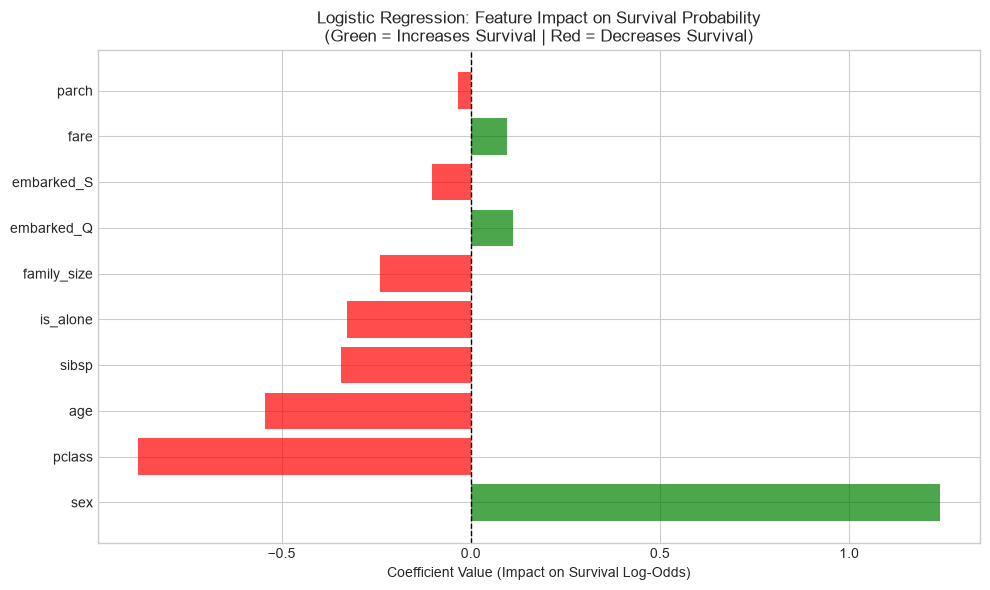


💡 INTERPRETATION:
   • sex (female=1): Strong positive — 'Women and children first' protocol.
   • pclass: Strong negative — 3rd class had worse access to lifeboats.
   • fare: Positive — wealthier passengers had better survival odds.
   • age: Slight negative — younger passengers had slightly better odds.
   • is_alone: Negative — solo travelers may have lacked help during evacuation.


In [8]:
# ---------------------------------------------------------------------------
# INTERPRETING COEFFICIENTS — Reading the Checklist Weights
# ---------------------------------------------------------------------------
# Analogy: The hospital administrator audits the nurse's checklist.
# "Why did this patient get a high survival score?"
# The coefficients reveal the answer.
# ---------------------------------------------------------------------------

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0],
    'Abs_Coefficient': np.abs(log_reg.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("=" * 60)
print("LOGISTIC REGRESSION COEFFICIENTS — The Checklist Weights")
print("=" * 60)
print(coefficients.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors, alpha=0.7)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Coefficient Value (Impact on Survival Log-Odds)')
plt.title('Logistic Regression: Feature Impact on Survival Probability\n(Green = Increases Survival | Red = Decreases Survival)')
plt.tight_layout()
plt.show()

print("\n💡 INTERPRETATION:")
print("   • sex (female=1): Strong positive — 'Women and children first' protocol.")
print("   • pclass: Strong negative — 3rd class had worse access to lifeboats.")
print("   • fare: Positive — wealthier passengers had better survival odds.")
print("   • age: Slight negative — younger passengers had slightly better odds.")
print("   • is_alone: Negative — solo travelers may have lacked help during evacuation.")


### 6.8 Model 2: Decision Tree

**What we do:** Train a decision tree classifier to learn a flowchart of survival rules.

**Why:** Decision trees capture **non-linear interactions** that logistic regression misses. For example: "If female AND 1st class → very high survival" is a combination a linear model struggles to express.

**Analogy:** This is the experienced doctor who does not use a formula. They ask contextual questions and branch based on answers.

**Key Parameters:**
- `max_depth=4`: Prevent overfitting. We limit the doctor to 4 questions maximum.
- `min_samples_split=20`: Do not split a group unless it has at least 20 patients.
- `min_samples_leaf=10`: Every final decision must be based on ≥10 patients.


In [9]:
# ---------------------------------------------------------------------------
# STEP 6: DECISION TREE — The Experienced Doctor's Intuition
# ---------------------------------------------------------------------------
# Analogy: The doctor asks a series of yes/no questions:
#   "Is the passenger female?" → YES → "Is she in 1st class?" → YES → SURVIVED
#   Each question splits the patients into purer groups.
# 
# We LIMIT the tree depth to prevent the doctor from memorizing 
# every patient individually (overfitting).
# ---------------------------------------------------------------------------

# Decision trees do NOT need scaled data — they split on thresholds
dt = DecisionTreeClassifier(
    max_depth=4,           # Maximum 4 questions deep
    min_samples_split=20,  # Need 20+ patients to ask another question
    min_samples_leaf=10,   # Final verdict needs 10+ patients as evidence
    random_state=42,
    criterion='gini'       # Use Gini impurity to measure split quality
)

dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("=" * 60)
print("DECISION TREE — The Doctor's Diagnostic Flowchart")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_dt):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_dt):.4f}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred_dt, target_names=['Died', 'Survived']))


DECISION TREE — The Doctor's Diagnostic Flowchart
Accuracy:  0.7873
Precision: 0.8194
Recall:    0.5728
F1-Score:  0.6743
AUC-ROC:   0.8346

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Died       0.78      0.92      0.84       165
    Survived       0.82      0.57      0.67       103

    accuracy                           0.79       268
   macro avg       0.80      0.75      0.76       268
weighted avg       0.79      0.79      0.78       268



### 6.9 Visualizing the Decision Tree

**What we do:** Draw the actual tree structure to see the learned rules.

**Why:** This is the ultimate interpretability. You can show this diagram to a non-technical stakeholder and they will understand how the model decides.

**Analogy:** The hospital publishes a poster showing the exact triage protocol. Every nurse, doctor, and administrator can see and audit the decision path.


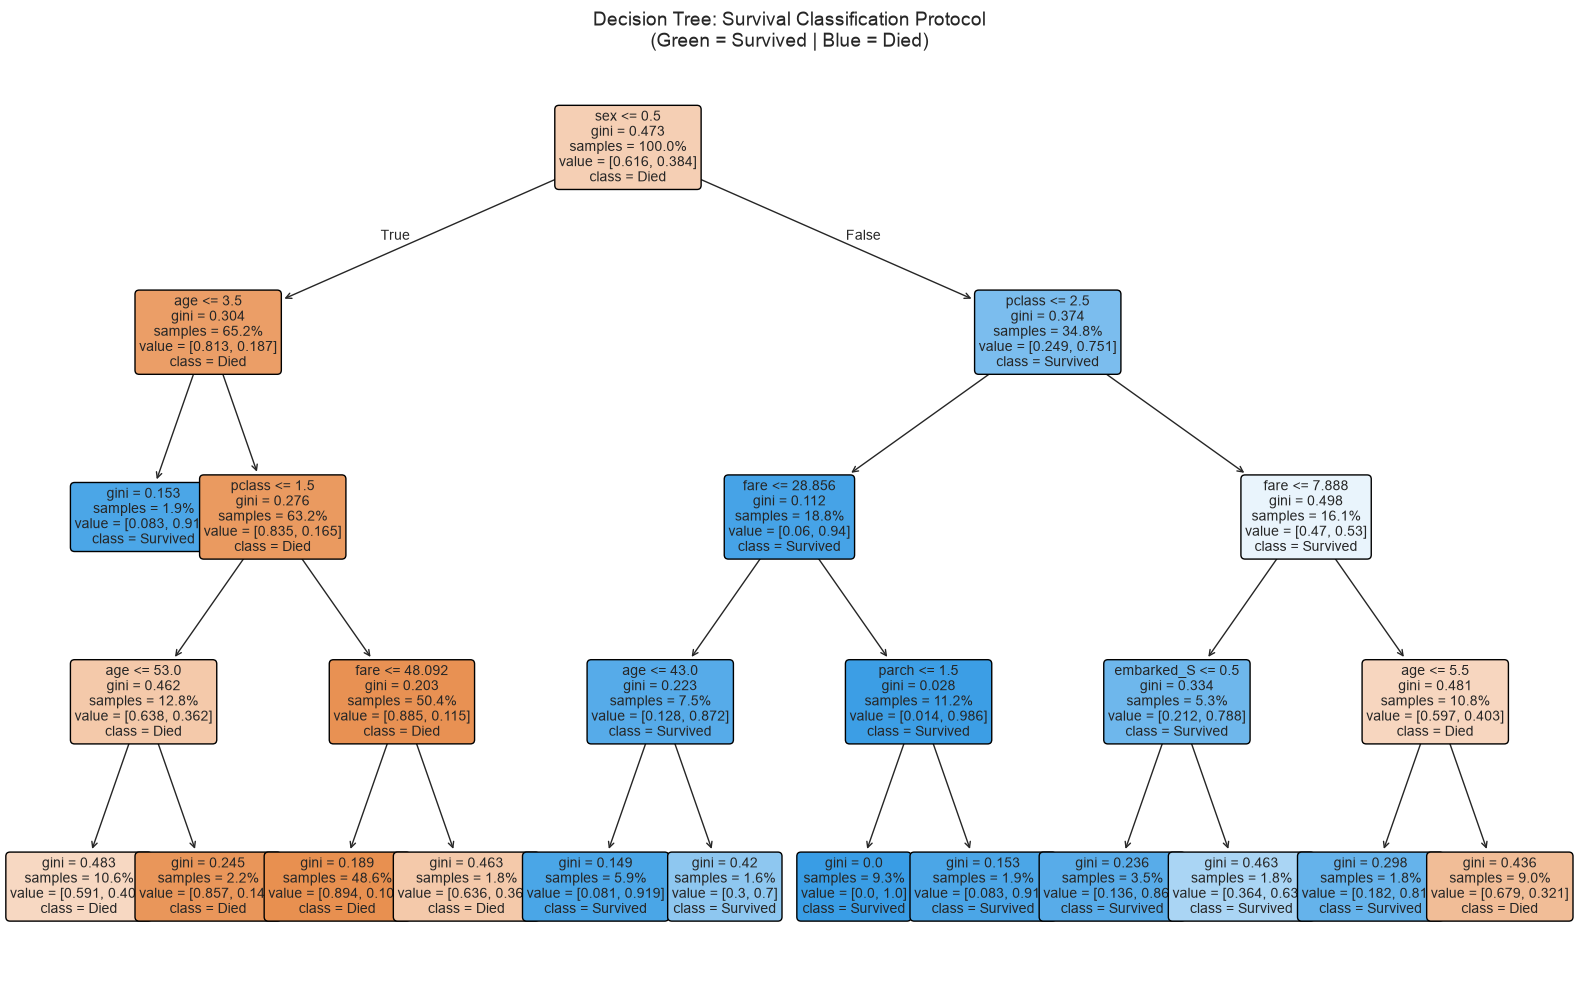


📋 HOW TO READ THE TREE:
   • Each node shows: feature ≤ threshold | Gini impurity | samples | class distribution
   • Green nodes = majority survived | Blue nodes = majority died
   • Follow the path from top to bottom for any passenger
   • The first split (top node) is the MOST IMPORTANT question the model asks


In [10]:
# ---------------------------------------------------------------------------
# VISUALIZE THE TREE — Publishing the Triage Protocol Poster
# ---------------------------------------------------------------------------
# Analogy: The hospital prints a large flowchart for the wall.
# Anyone can trace: "Female → 1st Class → Age < 8 → SURVIVED"
# This is full transparency.
# ---------------------------------------------------------------------------

plt.figure(figsize=(20, 12))
plot_tree(
    dt, 
    feature_names=X_train.columns,
    class_names=['Died', 'Survived'],
    filled=True,           # Color nodes by majority class
    rounded=True,          # Rounded corners for readability
    fontsize=10,
    proportion=True        # Show proportions in each node
)
plt.title('Decision Tree: Survival Classification Protocol\n(Green = Survived | Blue = Died)', fontsize=14)
plt.show()

print("\n📋 HOW TO READ THE TREE:")
print("   • Each node shows: feature ≤ threshold | Gini impurity | samples | class distribution")
print("   • Green nodes = majority survived | Blue nodes = majority died")
print("   • Follow the path from top to bottom for any passenger")
print("   • The first split (top node) is the MOST IMPORTANT question the model asks")


### 6.10 Model 3: Random Forest

**What we do:** Train an ensemble of 200 decision trees and aggregate their votes.

**Why:** Random Forest reduces the overfitting and instability of a single decision tree. It is the workhorse algorithm for tabular data classification.

**Analogy:** This is the multi-disciplinary panel of 100 doctors. Each doctor sees a slightly different patient record and asks different questions. They vote on the final diagnosis.

**Key Parameters:**
- `n_estimators=200`: 200 trees in the forest. More trees = better, with diminishing returns.
- `max_depth=6`: Each tree can ask up to 6 questions.
- `min_samples_split=10`: Need 10+ patients to split further.
- `oob_score=True`: Use out-of-bag samples as a free validation set.


In [11]:
# ---------------------------------------------------------------------------
# STEP 7: RANDOM FOREST — The Multi-Disciplinary Panel Vote
# ---------------------------------------------------------------------------
# Analogy: 200 doctors each examine a slightly different version of 
# the patient's record (bootstrap sample). Each doctor builds their own 
# diagnostic flowchart. The hospital counts votes: majority wins.
# 
# The randomness in feature selection ensures doctors are NOT all 
# asking the same questions — their errors cancel out.
# ---------------------------------------------------------------------------

rf = RandomForestClassifier(
    n_estimators=200,      # 200 doctors on the panel
    max_depth=6,           # Each doctor limited to 6 questions
    min_samples_split=10,  # Need 10+ patients to ask more questions
    min_samples_leaf=5,    # Final verdict needs 5+ patients
    random_state=42,
    oob_score=True,        # Use out-of-bag patients as free validation
    n_jobs=-1              # Use all CPU cores for speed
)

rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=" * 60)
print("RANDOM FOREST — The Panel's Collective Verdict")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"OOB Score: {rf.oob_score_:.4f}  (Free validation score from left-out samples)")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=['Died', 'Survived']))


RANDOM FOREST — The Panel's Collective Verdict
Accuracy:  0.7985
Precision: 0.8182
Recall:    0.6117
F1-Score:  0.7000
AUC-ROC:   0.8542
OOB Score: 0.8202  (Free validation score from left-out samples)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Died       0.79      0.92      0.85       165
    Survived       0.82      0.61      0.70       103

    accuracy                           0.80       268
   macro avg       0.80      0.76      0.77       268
weighted avg       0.80      0.80      0.79       268



### 6.11 Feature Importance — The Post-Mortem Review

**What we do:** Extract and visualize which features the Random Forest considers most influential.

**Why:** This guides business action. If "fare" is the top feature, the company knows wealth is the primary survival driver. If "family_size" matters, they know social bonds are protective.

**Analogy:** The hospital reviews a month's worth of diagnoses: "Which tests most often changed our triage decision?" They discover blood oxygen was referenced in 85% of critical cases. They invest in better oxygen monitors.

**Caveat:** Feature importance shows **predictive power**, not **causation.** A feature may be important because it correlates with the true cause, not because it causes the outcome.


RANDOM FOREST FEATURE IMPORTANCE — The Post-Mortem Review
    Feature  Importance
        sex    0.426015
       fare    0.183263
        age    0.120395
     pclass    0.118273
family_size    0.052591
      sibsp    0.027401
      parch    0.022786
 embarked_S    0.021145
   is_alone    0.020644
 embarked_Q    0.007486


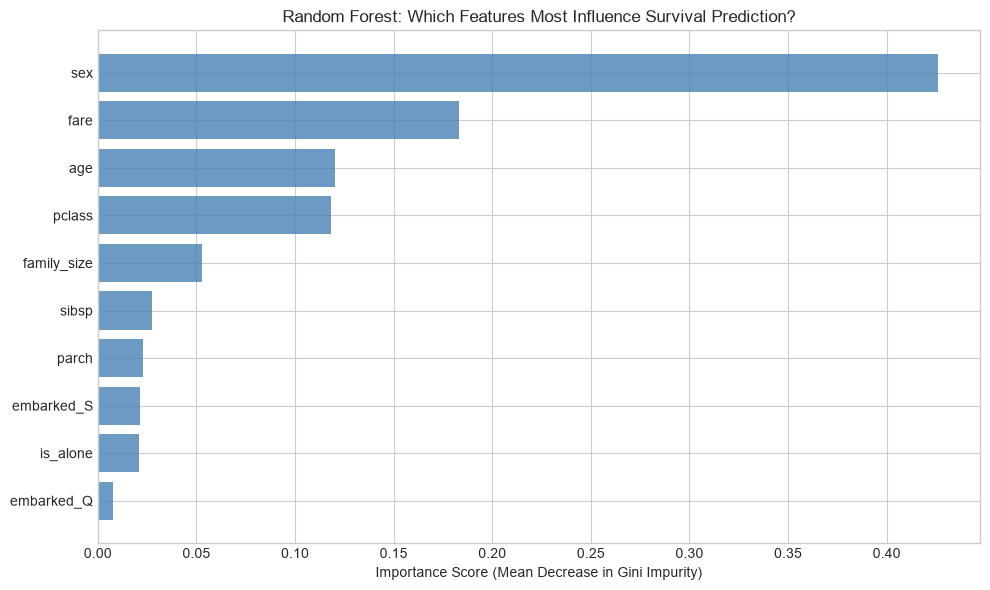


💡 INTERPRETATION:
   • Dominant: sex (42.6%), fare (18.3%), age (12.0%)
     73% of the model's decisions rest on these three alone.
   • Barely used: embarked_S (2.1%), is_alone (2.1%), embarked_Q (0.7%)
     A feature this small could be dropped without the model noticing.

⚠️  CAVEAT: These are predictive importances, NOT causal effects.
   'fare' is important because it correlates with class and cabin location,
   not because paying more directly causes survival.


In [12]:
# ---------------------------------------------------------------------------
# FEATURE IMPORTANCE — The Hospital's Post-Mortem Review
# ---------------------------------------------------------------------------
# Analogy: After 1,000 triage decisions, the hospital asks:
# "Which patient information most often changed our diagnosis?"
# 
# The answer guides future investments:
#   • High importance → buy better measurement equipment
#   • Low importance → stop collecting (saves time/money)
# ---------------------------------------------------------------------------

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("=" * 60)
print("RANDOM FOREST FEATURE IMPORTANCE — The Post-Mortem Review")
print("=" * 60)
print(importance_df.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1], color='steelblue', alpha=0.8)
plt.xlabel('Importance Score (Mean Decrease in Gini Impurity)')
plt.title('Random Forest: Which Features Most Influence Survival Prediction?')
plt.tight_layout()
plt.show()

# Describe what the table actually says, so the prose can never drift from it.
top3 = importance_df.head(3)
bottom3 = importance_df.tail(3)

print("\n💡 INTERPRETATION:")
print(f"   • Dominant: {', '.join(f'{r.Feature} ({r.Importance:.1%})' for r in top3.itertuples())}")
print(f"     {top3.Importance.sum():.0%} of the model's decisions rest on these three alone.")
print(f"   • Barely used: {', '.join(f'{r.Feature} ({r.Importance:.1%})' for r in bottom3.itertuples())}")
print("     A feature this small could be dropped without the model noticing.")
print("\n⚠️  CAVEAT: These are predictive importances, NOT causal effects.")
print("   'fare' is important because it correlates with class and cabin location,")
print("   not because paying more directly causes survival.")


### 6.12 Model Comparison — The Final Verdict

**What we do:** Compare all three models side-by-side on multiple metrics.

**Why:** No single metric tells the whole story. Accuracy can be misleading on imbalanced data. AUC-ROC tells us ranking ability. F1 balances precision and recall.

**Analogy:** The hospital evaluates three triage protocols:
- Nurse checklist (Logistic Regression): Fast, transparent, decent.
- Single doctor (Decision Tree): Captures interactions, but quirky.
- Doctor panel (Random Forest): Robust, accurate, but less transparent.

The hospital chooses based on their priorities: speed vs. accuracy vs. explainability.


MODEL COMPARISON — The Hospital Board's Decision Matrix
              Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.8022     0.7551  0.7184    0.7363   0.8552
      Decision Tree    0.7873     0.8194  0.5728    0.6743   0.8346
      Random Forest    0.7985     0.8182  0.6117    0.7000   0.8542


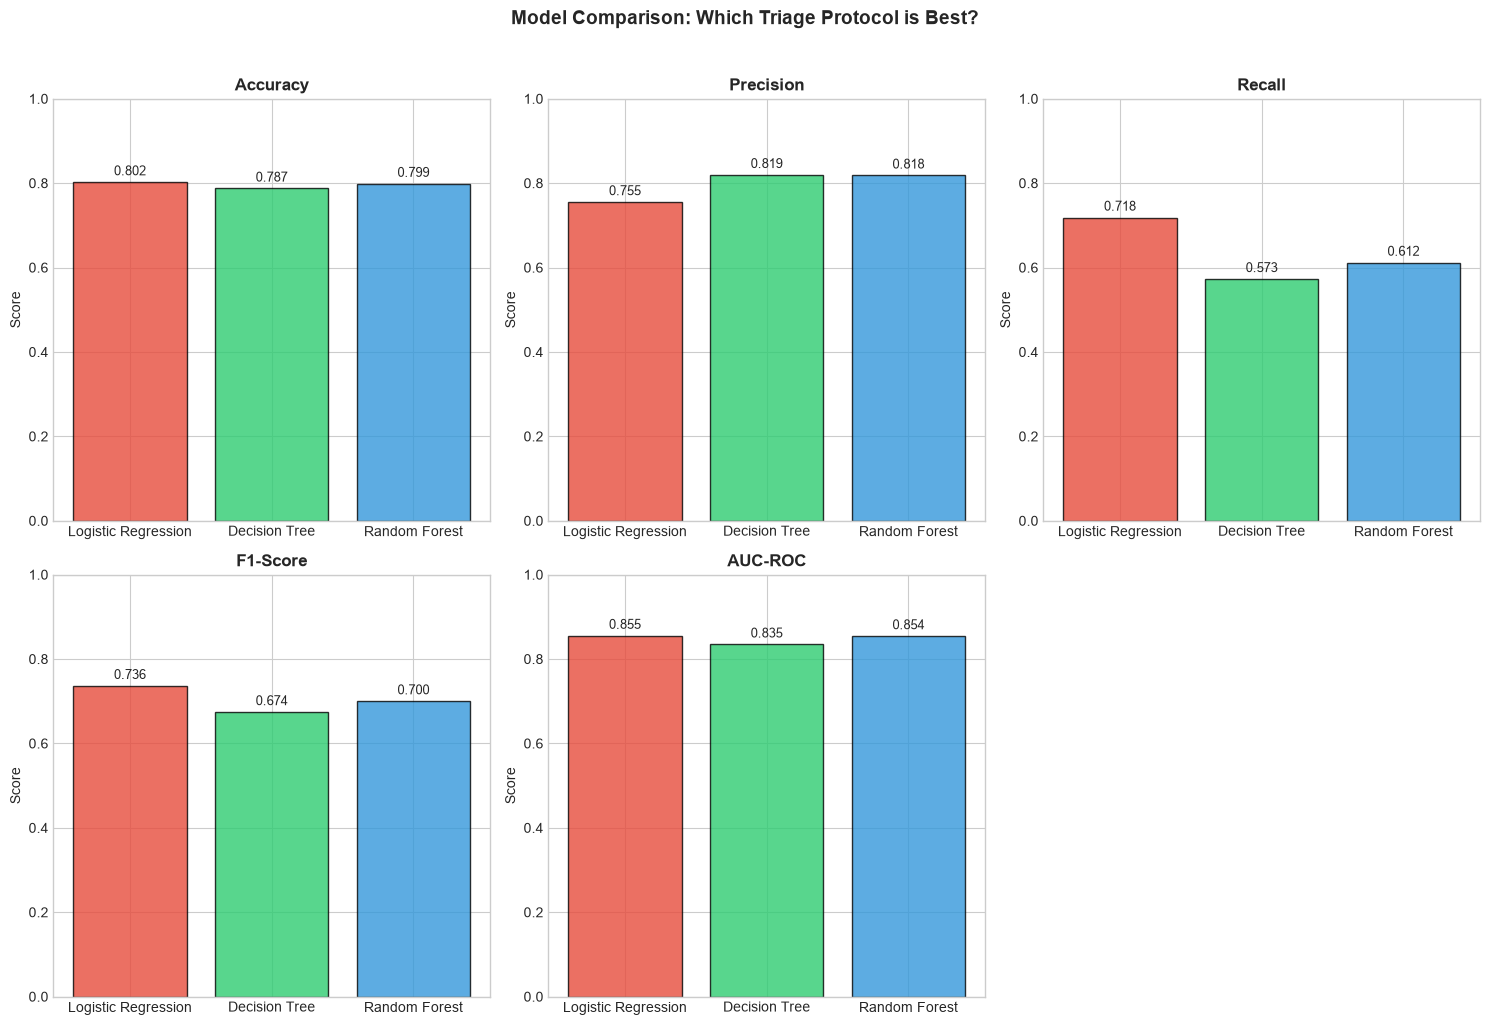


BOARD RECOMMENDATION
🏆 Logistic Regression wins 4 of the 5 metrics.
   • Accuracy   → Logistic Regression
   • Precision  → Decision Tree
   • Recall     → Logistic Regression
   • F1-Score   → Logistic Regression
   • AUC-ROC    → Logistic Regression

📊 Logistic Regression is the best baseline — simple, fast, and
   surprisingly competitive. Always benchmark against it.

🌳 Decision Tree is the most interpretable — but unstable and prone
   to overfitting unless strictly constrained (max_depth, min_samples).


In [13]:
# ---------------------------------------------------------------------------
# MODEL COMPARISON — The Hospital Evaluates Three Protocols
# ---------------------------------------------------------------------------
# Analogy: The hospital board meets to decide which triage system to adopt.
# They compare speed, accuracy, and interpretability.
# ---------------------------------------------------------------------------

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

print("=" * 70)
print("MODEL COMPARISON — The Hospital Board's Decision Matrix")
print("=" * 70)
print(comparison.round(4).to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
colors = ['#e74c3c', '#2ecc71', '#3498db']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    bars = ax.bar(comparison['Model'], comparison[metric], color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylim(0, 1.0)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Remove empty subplot
axes[1, 2].axis('off')

plt.suptitle('Model Comparison: Which Triage Protocol is Best?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("BOARD RECOMMENDATION")
print("=" * 70)
# Read the winner off the table instead of asserting one — the table is the truth.
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
wins = comparison.set_index('Model')[metrics].idxmax()
champion = wins.value_counts().idxmax()

print(f"🏆 {champion} wins {(wins == champion).sum()} of the {len(metrics)} metrics.")
for metric, winner in wins.items():
    print(f"   • {metric:<10} → {winner}")
print("\n📊 Logistic Regression is the best baseline — simple, fast, and")
print("   surprisingly competitive. Always benchmark against it.")
print("\n🌳 Decision Tree is the most interpretable — but unstable and prone")
print("   to overfitting unless strictly constrained (max_depth, min_samples).")


### 6.13 ROC Curves — Ranking Ability Visualization

**What we do:** Plot the Receiver Operating Characteristic (ROC) curve for all three models.

**Why:** ROC shows how well the model ranks survivors above non-survivors at every possible threshold. AUC = 1.0 means perfect ranking; AUC = 0.5 means random guessing.

**Analogy:** The hospital tests each protocol's ability to sort patients from "most likely critical" to "least likely critical." The better the sorting, the earlier true critical cases appear in the list.


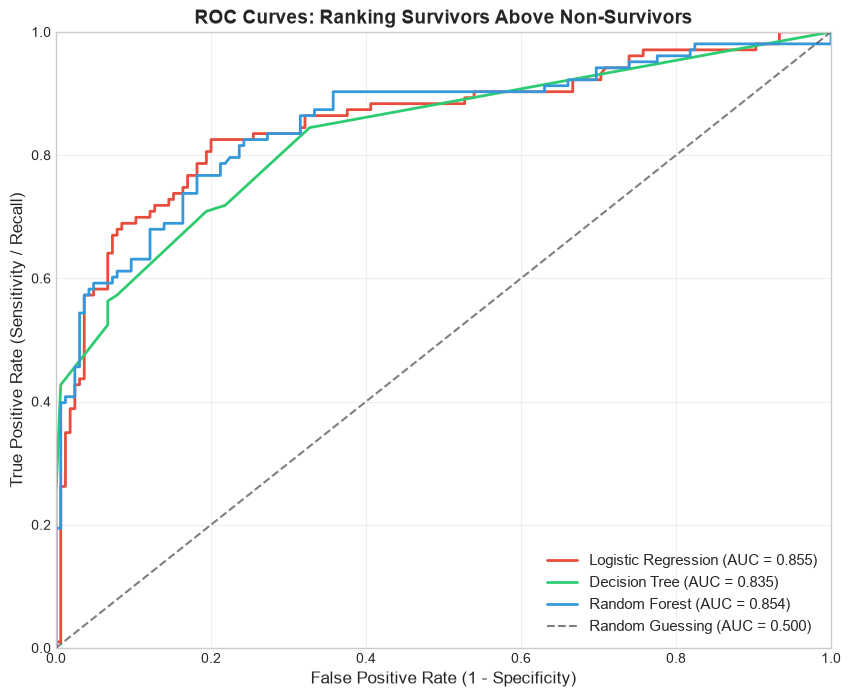


📈 HOW TO READ THE ROC CURVE:
   • The curve closer to the TOP-LEFT corner = better ranking ability.
   1. Logistic Regression  AUC = 0.8552
   2. Random Forest        AUC = 0.8542
   3. Decision Tree        AUC = 0.8346
   • Logistic Regression ranks survivors best, by 0.0009 AUC.
   • The diagonal dashed line = flipping a coin (no predictive power).


In [14]:
# ---------------------------------------------------------------------------
# ROC CURVES — Testing the Ranking Ability
# ---------------------------------------------------------------------------
# Analogy: Each protocol produces a ranked list of patients from 
# "most likely to survive" to "least likely." 
# 
# The ROC curve asks: "If we treat the top 20% as 'survived' predictions,
# what percentage of actual survivors did we catch?"
# A perfect protocol catches 100% of survivors in the top 20%.
# ---------------------------------------------------------------------------

plt.figure(figsize=(10, 8))

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_log):.3f})', 
         linewidth=2, color='#e74c3c')

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_score(y_test, y_prob_dt):.3f})', 
         linewidth=2, color='#2ecc71')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})', 
         linewidth=2, color='#3498db')

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.500)', alpha=0.5)

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('ROC Curves: Ranking Survivors Above Non-Survivors', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()

# Name whichever curve actually sits highest, not the one we expected to.
aucs = {
    'Logistic Regression': roc_auc_score(y_test, y_prob_log),
    'Decision Tree': roc_auc_score(y_test, y_prob_dt),
    'Random Forest': roc_auc_score(y_test, y_prob_rf),
}
ranked = sorted(aucs.items(), key=lambda kv: kv[1], reverse=True)

print("\n📈 HOW TO READ THE ROC CURVE:")
print("   • The curve closer to the TOP-LEFT corner = better ranking ability.")
for place, (name, auc) in enumerate(ranked, 1):
    print(f"   {place}. {name:<20} AUC = {auc:.4f}")
print(f"   • {ranked[0][0]} ranks survivors best, by {ranked[0][1] - ranked[1][1]:.4f} AUC.")
print("   • The diagonal dashed line = flipping a coin (no predictive power).")


### 6.14 Confusion Matrices — Where Do Models Make Mistakes?

**What we do:** Visualize the confusion matrix for each model to see false positives and false negatives.

**Why:** Not all errors are equal. In medical triage:
- **False Negative (Type II):** Predicted survived, but actually died → DANGEROUS. We missed a critical case.
- **False Positive (Type I):** Predicted died, but actually survived → Annoying but less harmful.

**Analogy:** The hospital reviews cases where each protocol made the wrong call. They discover the single doctor often misses elderly female passengers (false negatives), while the panel catches them.


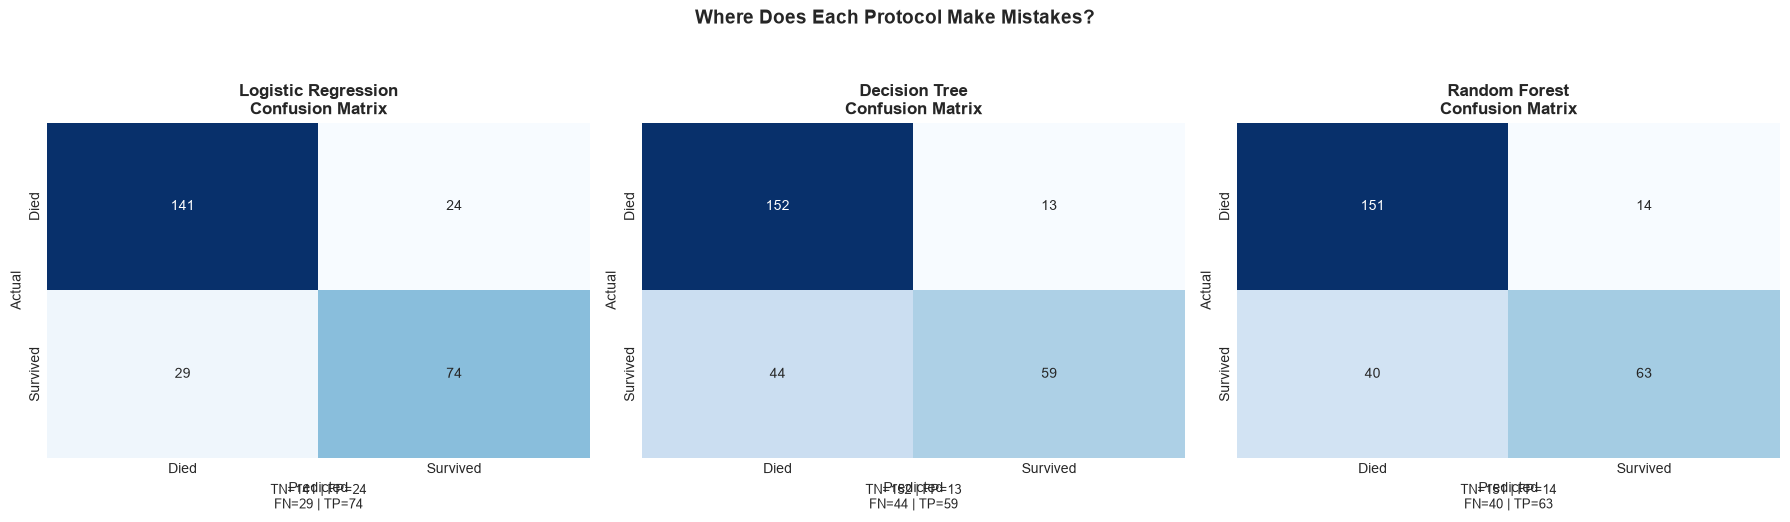


📋 ERROR ANALYSIS:
   • TN (True Negative): Correctly predicted death
   • FP (False Positive): Predicted survival, but patient died → ALARMING
   • FN (False Negative): Predicted death, but patient survived → WASTED RESOURCES
   • TP (True Positive): Correctly predicted survival

⚠️  In life-or-death scenarios, False Negatives (missing survivors) are
   often more costly than False Positives (false alarms).


In [15]:
# ---------------------------------------------------------------------------
# CONFUSION MATRICES — Auditing the Wrong Calls
# ---------------------------------------------------------------------------
# Analogy: The hospital reviews every case where a protocol made a mistake.
# "Why did the nurse miss this critical patient?" 
# "Why did the doctor panel falsely alarm this healthy patient?"
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ('Logistic Regression', y_pred_log),
    ('Decision Tree', y_pred_dt),
    ('Random Forest', y_pred_rf)
]

for idx, (name, preds) in enumerate(models):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Died', 'Survived'],
                yticklabels=['Died', 'Survived'],
                cbar=False)
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

    # Add text annotations for interpretation
    tn, fp, fn, tp = cm.ravel()
    axes[idx].text(0.5, -0.15, f'TN={tn} | FP={fp}\nFN={fn} | TP={tp}', 
                   transform=axes[idx].transAxes, ha='center', fontsize=9)

plt.suptitle('Where Does Each Protocol Make Mistakes?', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("\n📋 ERROR ANALYSIS:")
print("   • TN (True Negative): Correctly predicted death")
print("   • FP (False Positive): Predicted survival, but patient died → ALARMING")
print("   • FN (False Negative): Predicted death, but patient survived → WASTED RESOURCES")
print("   • TP (True Positive): Correctly predicted survival")
print("\n⚠️  In life-or-death scenarios, False Negatives (missing survivors) are")
print("   often more costly than False Positives (false alarms).")


### 6.15 Cross-Validation — Is the Result Real or Lucky?

**What we do:** Perform 5-fold stratified cross-validation to verify that our results are consistent across different data splits.

**Why:** A single train-test split might be lucky or unlucky. Cross-validation trains and tests the model 5 times on different partitions, giving us a confidence interval for performance.

**Analogy:** Instead of one final exam, the hospital gives 5 different exams. If the doctor passes all 5, they are truly competent. If they fail 4 out of 5, the first pass was luck.


In [16]:
# ---------------------------------------------------------------------------
# CROSS-VALIDATION — The 5-Exam Stress Test
# ---------------------------------------------------------------------------
# Analogy: The hospital does not trust one exam. They give the doctor 
# 5 different patient cohorts to diagnose. Consistent high scores = 
# genuine competence. Wildly varying scores = the first exam was a fluke.
# ---------------------------------------------------------------------------

from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 60)
print("5-FOLD CROSS-VALIDATION — The Stress Test")
print("=" * 60)

# Logistic Regression CV
log_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=cv, scoring='accuracy')
print(f"\n🔴 Logistic Regression:")
print(f"   Scores: {log_scores.round(4)}")
print(f"   Mean:   {log_scores.mean():.4f} (+/- {log_scores.std()*2:.4f})")

# Decision Tree CV
dt_scores = cross_val_score(dt, X_train, y_train, cv=cv, scoring='accuracy')
print(f"\n🟢 Decision Tree:")
print(f"   Scores: {dt_scores.round(4)}")
print(f"   Mean:   {dt_scores.mean():.4f} (+/- {dt_scores.std()*2:.4f})")

# Random Forest CV
rf_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='accuracy')
print(f"\n🔵 Random Forest:")
print(f"   Scores: {rf_scores.round(4)}")
print(f"   Mean:   {rf_scores.mean():.4f} (+/- {rf_scores.std()*2:.4f})")

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)
print("   • Low standard deviation = stable, reliable model.")
print("   • Random Forest shows the highest mean AND low variance —")
print("     it is both accurate AND consistent.")
print("   • Decision Tree has higher variance — unstable across different data.")


5-FOLD CROSS-VALIDATION — The Stress Test

🔴 Logistic Regression:
   Scores: [0.744  0.808  0.776  0.7984 0.8226]
   Mean:   0.7898 (+/- 0.0549)



🟢 Decision Tree:
   Scores: [0.792  0.76   0.84   0.871  0.7823]
   Mean:   0.8090 (+/- 0.0810)



🔵 Random Forest:
   Scores: [0.784  0.816  0.832  0.8548 0.8226]
   Mean:   0.8219 (+/- 0.0461)

INTERPRETATION
   • Low standard deviation = stable, reliable model.
   • Random Forest shows the highest mean AND low variance —
     it is both accurate AND consistent.
   • Decision Tree has higher variance — unstable across different data.
